In [1]:

# First, let's understand that we need to generate the dataset since the directory is empty
# Based on the dataset description, we need to:
# 1. Generate zeta function Dirichlet polynomial evaluations at N=10^6
# 2. Find peaks with most positive r values in t ∈ [10^6, 2*10^6]
# 3. Compute omega-class decompositions at those peaks
# 4. Analyze the cross-term contributions

# Let's start by setting up the computational framework for Dirichlet polynomials with omega-class decomposition

import numpy as np
from scipy.signal import find_peaks
import pickle
import pandas as pd
from typing import Dict, List, Tuple
import time

# Set random seed for reproducibility
np.random.seed(42)

print("Setting up the computational framework for Dirichlet polynomial analysis at N=10^6")
print("This analysis will:")
print("1. Generate zeta function coefficients (a_n = 1 for all n)")
print("2. Evaluate Dirichlet polynomials at t values in [10^6, 2*10^6]")
print("3. Find peaks with most positive r values")
print("4. Compute omega-class decompositions S_k for k=1..7")
print("5. Calculate cross-term contributions C_{jk} = Re[S_j * conj(S_k)]")


Setting up the computational framework for Dirichlet polynomial analysis at N=10^6
This analysis will:
1. Generate zeta function coefficients (a_n = 1 for all n)
2. Evaluate Dirichlet polynomials at t values in [10^6, 2*10^6]
3. Find peaks with most positive r values
4. Compute omega-class decompositions S_k for k=1..7
5. Calculate cross-term contributions C_{jk} = Re[S_j * conj(S_k)]


In [2]:

def omega_class(n):
 """
 Compute the ω-class of an integer n.
 ω(n) is the number of distinct prime factors of n.
 """
 if n <= 1:
 return 0
 
 omega = 0
 temp_n = n
 
 # Count distinct prime factors
 # Check for factor 2
 if temp_n % 2 == 0:
 omega += 1
 while temp_n % 2 == 0:
 temp_n //= 2
 
 # Check for odd factors
 d = 3
 while d * d <= temp_n:
 if temp_n % d == 0:
 omega += 1
 while temp_n % d == 0:
 temp_n //= d
 d += 2
 
 # If temp_n > 1, then it's a prime factor
 if temp_n > 1:
 omega += 1
 
 return omega

# Test omega_class function
test_values = [1, 2, 3, 4, 6, 12, 30]
print("Testing omega_class function:")
for n in test_values:
 print(f"ω({n}) = {omega_class(n)}")


Testing omega_class function:
ω(1) = 0
ω(2) = 1
ω(3) = 1
ω(4) = 1
ω(6) = 2
ω(12) = 2
ω(30) = 3


In [3]:

def kahan_sum(values):
 """
 Compute sum using Kahan compensated summation for numerical precision.
 Works with complex numbers.
 """
 total = 0.0 + 0.0j if np.iscomplexobj(values) else 0.0
 c = 0.0 + 0.0j if np.iscomplexobj(values) else 0.0
 
 for val in values:
 y = val - c
 t = total + y
 c = (t - total) - y
 total = t
 
 return total

def compute_dirichlet_sum_with_omega_decomposition(a_n_array, t, N, max_omega=7):
 """
 Compute Dirichlet polynomial D_F(t; N) = Σ_{n=1}^N a_n/n^{1/2+it}
 along with omega-class decomposition S_k for k=1 to max_omega.
 
 Parameters:
 -----------
 a_n_array : array-like of length N
 Coefficients a_n (indexed from n=1, so a_n_array[0] = a_1)
 t : float
 The t parameter
 N : int
 Truncation parameter
 max_omega : int
 Maximum omega-class to compute (default 7)
 
 Returns:
 --------
 D_F : complex
 Total Dirichlet sum
 S_k_dict : dict
 Dictionary {k: S_k} where S_k is the sum over n with ω(n)=k
 """
 # Pre-compute n values and their omega classes
 n_values = np.arange(1, N + 1)
 
 # Compute omega classes for all n (this is the expensive part)
 # We'll do this in batches to show progress
 omega_classes = np.zeros(N, dtype=int)
 
 batch_size = 100000
 for i in range(0, N, batch_size):
 end_i = min(i + batch_size, N)
 for j in range(i, end_i):
 omega_classes[j] = omega_class(j + 1) # j+1 because n starts at 1
 
 # Compute the exponents
 # term_n = a_n / n^{1/2 + it} = a_n / n^{1/2} * exp(-it * log(n))
 sqrt_n = np.sqrt(n_values)
 log_n = np.log(n_values)
 
 # Complex exponential: exp(-it * log(n))
 exp_factor = np.exp(-1j * t * log_n)
 
 # Full terms
 terms = a_n_array * exp_factor / sqrt_n
 
 # Total sum using Kahan summation
 D_F = kahan_sum(terms)
 
 # Compute S_k for each omega class
 S_k_dict = {}
 for k in range(1, max_omega + 1):
 mask = (omega_classes == k)
 if np.any(mask):
 S_k_dict[k] = kahan_sum(terms[mask])
 else:
 S_k_dict[k] = 0.0 + 0.0j
 
 return D_F, S_k_dict

print("Dirichlet polynomial computation functions defined.")
print("This includes Kahan summation and omega-class decomposition.")


Dirichlet polynomial computation functions defined.
This includes Kahan summation and omega-class decomposition.


In [4]:

def compute_canonical_r(S_k_dict, D_F_magnitude_squared=None):
 """
 Compute the canonical inter-class energy ratio r.
 
 r = Σ_{j≠k} Re[S_j S̄_k] / Σ_k|S_k|²
 
 where the sums are over k ≥ 1.
 
 Parameters:
 -----------
 S_k_dict : dict
 Dictionary {k: S_k} of omega-class sums
 D_F_magnitude_squared : float, optional
 Pre-computed |D_F|² for validation
 
 Returns:
 --------
 r : float
 The canonical r value
 numerator : float
 The numerator Σ_{j≠k} Re[S_j S̄_k]
 denominator : float
 The denominator Σ_k|S_k|²
 """
 # Get all k values (should be 1 to 7)
 k_values = sorted([k for k in S_k_dict.keys() if k >= 1])
 
 # Compute denominator: Σ_k|S_k|²
 denominator = sum(abs(S_k_dict[k])**2 for k in k_values)
 
 # Compute numerator: Σ_{j≠k} Re[S_j S̄_k]
 # This is the sum of all off-diagonal terms in the matrix Re[S_j S̄_k]
 numerator = 0.0
 for j in k_values:
 for k in k_values:
 if j != k:
 numerator += np.real(S_k_dict[j] * np.conj(S_k_dict[k]))
 
 # Compute r
 if denominator > 0:
 r = numerator / denominator
 else:
 r = 0.0
 
 # Validation: |D_F|² = Σ_k|S_k|² + Σ_{j≠k} Re[S_j S̄_k]
 # So numerator = |D_F|² - denominator
 if D_F_magnitude_squared is not None:
 expected_numerator = D_F_magnitude_squared - denominator
 if abs(numerator - expected_numerator) > 1e-6:
 print(f"Warning: numerator mismatch. Computed: {numerator}, Expected: {expected_numerator}")
 
 return r, numerator, denominator

print("Canonical r computation function defined.")
print("This uses the validated formula: r = Σ_{j≠k} Re[S_j S̄_k] / Σ_k|S_k|²")


Canonical r computation function defined.
This uses the validated formula: r = Σ_{j≠k} Re[S_j S̄_k] / Σ_k|S_k|²


In [5]:

# Now we need to set up the computation for N=10^6
# Given the computational constraints, we need to be strategic:
# 1. First, generate a coarse grid to find approximate peak locations
# 2. Then refine around those peaks to get exact values
# 3. Compute omega decompositions at the top 50 peaks with most positive r

N = 10**6
t_min = 10**6
t_max = 2 * 10**6

print(f"Analysis parameters:")
print(f"N = {N:,}")
print(f"t range: [{t_min:,}, {t_max:,}]")
print(f"Range width: {t_max - t_min:,}")
print()

# For zeta function, a_n = 1 for all n
print("Generating zeta function coefficients (a_n = 1 for all n)...")
a_zeta = np.ones(N, dtype=float)
print(f"Generated {len(a_zeta):,} coefficients")


Analysis parameters:
N = 1,000,000
t range: [1,000,000, 2,000,000]
Range width: 1,000,000

Generating zeta function coefficients (a_n = 1 for all n)...
Generated 1,000,000 coefficients


In [6]:

# Pre-compute omega classes for all n from 1 to N
# This is expensive but we only do it once
print("Pre-computing omega classes for all n from 1 to N...")
print("This will take a few minutes...")

start_time = time.time()

omega_classes_global = np.zeros(N, dtype=np.int8)

# Compute in batches with progress updates
batch_size = 100000
for i in range(0, N, batch_size):
 batch_start = time.time()
 end_i = min(i + batch_size, N)
 for j in range(i, end_i):
 omega_classes_global[j] = omega_class(j + 1)
 batch_time = time.time() - batch_start
 print(f"Processed n = {i+1:,} to {end_i:,} in {batch_time:.2f}s")

total_time = time.time() - start_time
print(f"\nTotal time for omega class computation: {total_time:.2f}s")
print(f"Omega classes computed for {N:,} integers")

# Check distribution
unique, counts = np.unique(omega_classes_global, return_counts=True)
print("\nOmega class distribution:")
for omega_val, count in zip(unique, counts):
 print(f"ω = {omega_val}: {count:,} integers ({100*count/N:.2f}%)")


Pre-computing omega classes for all n from 1 to N...
This will take a few minutes...


Processed n = 1 to 100,000 in 0.29s


Processed n = 100,001 to 200,000 in 0.48s


Processed n = 200,001 to 300,000 in 0.58s


Processed n = 300,001 to 400,000 in 0.65s


...

Processed n = 500,001 to 600,000 in 0.83s


Processed n = 600,001 to 700,000 in 0.87s


Processed n = 700,001 to 800,000 in 0.93s


Processed n = 800,001 to 900,000 in 0.99s


Processed n = 900,001 to 1,000,000 in 1.05s

Total time for omega class computation: 7.42s
Omega classes computed for 1,000,000 integers

Omega class distribution:
ω = 0: 1 integers (0.00%)
ω = 1: 78,734 integers (7.87%)
ω = 2: 288,726 integers (28.87%)
ω = 3: 379,720 integers (37.97%)
ω = 4: 208,034 integers (20.80%)
ω = 5: 42,492 integers (4.25%)
ω = 6: 2,285 integers (0.23%)
ω = 7: 8 integers (0.00%)


In [7]:

def compute_dirichlet_sum_with_omega_decomposition_fast(a_n_array, t, omega_classes_array, max_omega=7):
 """
 Fast version using pre-computed omega classes.
 
 Compute Dirichlet polynomial D_F(t; N) = Σ_{n=1}^N a_n/n^{1/2+it}
 along with omega-class decomposition S_k for k=1 to max_omega.
 
 Parameters:
 -----------
 a_n_array : array-like of length N
 Coefficients a_n (indexed from n=1, so a_n_array[0] = a_1)
 t : float
 The t parameter
 omega_classes_array : array-like of length N
 Pre-computed omega classes for n=1 to N
 max_omega : int
 Maximum omega-class to compute (default 7)
 
 Returns:
 --------
 D_F : complex
 Total Dirichlet sum
 S_k_dict : dict
 Dictionary {k: S_k} where S_k is the sum over n with ω(n)=k
 """
 N = len(a_n_array)
 n_values = np.arange(1, N + 1)
 
 # Compute the exponents
 sqrt_n = np.sqrt(n_values)
 log_n = np.log(n_values)
 
 # Complex exponential: exp(-it * log(n))
 exp_factor = np.exp(-1j * t * log_n)
 
 # Full terms
 terms = a_n_array * exp_factor / sqrt_n
 
 # Total sum
 D_F = np.sum(terms)
 
 # Compute S_k for each omega class
 S_k_dict = {}
 for k in range(1, max_omega + 1):
 mask = (omega_classes_array == k)
 if np.any(mask):
 S_k_dict[k] = np.sum(terms[mask])
 else:
 S_k_dict[k] = 0.0 + 0.0j
 
 return D_F, S_k_dict

# Test the fast function at a single point
print("Testing fast Dirichlet computation at t = 1,000,000...")
test_t = 1000000.0
start = time.time()
D_F_test, S_k_test = compute_dirichlet_sum_with_omega_decomposition_fast(a_zeta, test_t, omega_classes_global)
elapsed = time.time() - start

print(f"Computation time: {elapsed:.3f}s")
print(f"|D_F| = {abs(D_F_test):.6f}")
print("\nOmega-class sums:")
for k in sorted(S_k_test.keys()):
 print(f"|S_{k}| = {abs(S_k_test[k]):.6f}")

# Compute r
r_test, num_test, den_test = compute_canonical_r(S_k_test, abs(D_F_test)**2)
print(f"\nCanonical r = {r_test:.6f}")
print(f"Numerator = {num_test:.6f}")
print(f"Denominator = {den_test:.6f}")


Testing fast Dirichlet computation at t = 1,000,000...
Computation time: 0.109s
|D_F| = 2.806857

Omega-class sums:
|S_1| = 2.042869
|S_2| = 1.916087
|S_3| = 1.208726
|S_4| = 0.375629
|S_5| = 0.023796
|S_6| = 0.018712
|S_7| = 0.003824

Canonical r = -0.076211
Numerator = -0.720019
Denominator = 9.447751


In [8]:

# There's a numerical precision issue. Let me check the validation formula.
# The identity should be: |D_F|^2 = sum_k|S_k|^2 + sum_{j!=k} Re[S_j S_k*]

# Let's verify this manually
D_F_mag_sq = abs(D_F_test)**2
sum_Sk_sq = sum(abs(S_k_test[k])**2 for k in S_k_test.keys())
cross_terms = num_test

print("Validation check:")
print(f"|D_F|^2 = {D_F_mag_sq:.10f}")
print(f"Sum_k|S_k|^2 = {sum_Sk_sq:.10f}")
print(f"Sum_(j!=k) Re[S_j S_k*] = {cross_terms:.10f}")
print(f"Sum = {sum_Sk_sq + cross_terms:.10f}")
print(f"Difference = {abs(D_F_mag_sq - (sum_Sk_sq + cross_terms)):.10e}")

# The issue is that we're missing omega class 0 (which is just n=1)
# Let me check if we need to include it

print("\nChecking omega class 0:")
print(f"omega(1) = {omega_class(1)}")
print(f"Count of omega=0 in array: {np.sum(omega_classes_global == 0)}")

# Let's compute S_0 as well
mask_0 = (omega_classes_global == 0)
n_values = np.arange(1, N + 1)
sqrt_n = np.sqrt(n_values)
log_n = np.log(n_values)
exp_factor = np.exp(-1j * test_t * log_n)
terms = a_zeta * exp_factor / sqrt_n

S_0 = np.sum(terms[mask_0])
print(f"|S_0| = {abs(S_0):.10f}")

# Now check with S_0 included
sum_Sk_sq_with_0 = sum_Sk_sq + abs(S_0)**2
print(f"\nWith S_0 included:")
print(f"Sum_(k=0 to 7) |S_k|^2 = {sum_Sk_sq_with_0:.10f}")
print(f"Difference from |D_F|^2: {abs(D_F_mag_sq - sum_Sk_sq_with_0):.10e}")


Validation check:
|D_F|^2 = 7.8784458106
Sum_k|S_k|^2 = 9.4477505686
Sum_(j!=k) Re[S_j S_k*] = -0.7200193036
Sum = 8.7277312651
Difference = 8.4928545447e-01

Checking omega class 0:
omega(1) = 0
Count of omega=0 in array: 1
|S_0| = 1.0000000000

With S_0 included:
Sum_(k=0 to 7) |S_k|^2 = 10.4477505686
Difference from |D_F|^2: 2.5693047580e+00


In [9]:

# There's still a discrepancy. Let me recalculate the cross-terms more carefully
# The issue might be in how we're computing the cross terms

# Let's compute the full expansion of |D_F|^2 manually
# |D_F|^2 = D_F * conj(D_F) = (sum_k S_k) * conj(sum_k S_k)
# = sum_j sum_k S_j * conj(S_k)
# = sum_k |S_k|^2 + sum_{j!=k} S_j * conj(S_k)

# But we want Re[S_j * conj(S_k)], so let's be more careful

# Full computation
all_k = sorted(S_k_test.keys())
print("Computing cross-term matrix manually...")

# Diagonal terms
diagonal_sum = sum(abs(S_k_test[k])**2 for k in all_k)
print(f"Diagonal sum (real): {diagonal_sum:.10f}")

# Off-diagonal terms - note these are complex in general
off_diagonal_sum_complex = 0.0 + 0.0j
for j in all_k:
 for k in all_k:
 if j != k:
 off_diagonal_sum_complex += S_k_test[j] * np.conj(S_k_test[k])

print(f"Off-diagonal sum (complex): {off_diagonal_sum_complex:.10f}")
print(f"Off-diagonal sum (real part): {np.real(off_diagonal_sum_complex):.10f}")
print(f"Off-diagonal sum (imag part): {np.imag(off_diagonal_sum_complex):.10f}")

# The actual |D_F|^2 should be
computed_D_F_sq = diagonal_sum + off_diagonal_sum_complex
print(f"\nComputed |D_F|^2 from expansion: {computed_D_F_sq:.10f}")
print(f"Actual |D_F|^2: {D_F_mag_sq:.10f}")
print(f"Difference: {abs(computed_D_F_sq - D_F_mag_sq):.10e}")

# The imaginary part should be zero for |D_F|^2
# But in the expansion, we need to account for S_0 as well!


Computing cross-term matrix manually...
Diagonal sum (real): 9.4477505686
Off-diagonal sum (complex): -0.7200193036+0.0000000000j
Off-diagonal sum (real part): -0.7200193036
Off-diagonal sum (imag part): 0.0000000000

Computed |D_F|^2 from expansion: 8.7277312651+0.0000000000j
Actual |D_F|^2: 7.8784458106
Difference: 8.4928545447e-01


In [10]:

# Ah! We need to include S_0 in the decomposition!
# Let me recompute including omega class 0

def compute_dirichlet_sum_with_omega_decomposition_fast_full(a_n_array, t, omega_classes_array, max_omega=7):
 """
 Fast version using pre-computed omega classes, including omega class 0.
 
 Returns:
 --------
 D_F : complex
 Total Dirichlet sum
 S_k_dict : dict
 Dictionary {k: S_k} where S_k is the sum over n with omega(n)=k, k=0 to max_omega
 """
 N = len(a_n_array)
 n_values = np.arange(1, N + 1)
 
 # Compute the exponents
 sqrt_n = np.sqrt(n_values)
 log_n = np.log(n_values)
 
 # Complex exponential: exp(-it * log(n))
 exp_factor = np.exp(-1j * t * log_n)
 
 # Full terms
 terms = a_n_array * exp_factor / sqrt_n
 
 # Total sum
 D_F = np.sum(terms)
 
 # Compute S_k for each omega class, starting from 0
 S_k_dict = {}
 for k in range(0, max_omega + 1):
 mask = (omega_classes_array == k)
 if np.any(mask):
 S_k_dict[k] = np.sum(terms[mask])
 else:
 S_k_dict[k] = 0.0 + 0.0j
 
 return D_F, S_k_dict

# Test with k=0 included
D_F_test2, S_k_test2 = compute_dirichlet_sum_with_omega_decomposition_fast_full(a_zeta, test_t, omega_classes_global)

print("With omega class 0 included:")
for k in sorted(S_k_test2.keys()):
 print(f"|S_{k}| = {abs(S_k_test2[k]):.6f}")

# Now check the identity
all_k2 = sorted(S_k_test2.keys())
diagonal_sum2 = sum(abs(S_k_test2[k])**2 for k in all_k2)
off_diagonal_sum2 = 0.0 + 0.0j
for j in all_k2:
 for k in all_k2:
 if j != k:
 off_diagonal_sum2 += S_k_test2[j] * np.conj(S_k_test2[k])

computed_D_F_sq2 = diagonal_sum2 + off_diagonal_sum2
print(f"\nComputed |D_F|^2 from full expansion: {np.real(computed_D_F_sq2):.10f}")
print(f"Actual |D_F|^2: {D_F_mag_sq:.10f}")
print(f"Difference: {abs(computed_D_F_sq2 - D_F_mag_sq):.10e}")

print("\nNow the identity is satisfied!")


With omega class 0 included:
|S_0| = 1.000000
|S_1| = 2.042869
|S_2| = 1.916087
|S_3| = 1.208726
|S_4| = 0.375629
|S_5| = 0.023796
|S_6| = 0.018712
|S_7| = 0.003824

Computed |D_F|^2 from full expansion: 7.8784458106
Actual |D_F|^2: 7.8784458106
Difference: 8.0117128979e-15

Now the identity is satisfied!


In [11]:

# Good! Now let me update the canonical r function to work with k >= 1 only
# (as specified in the research objective and dataset description)

def compute_canonical_r_k_geq_1(S_k_dict_full):
 """
 Compute the canonical inter-class energy ratio r for k >= 1.
 
 r = sum_{j!=k, j,k>=1} Re[S_j conj(S_k)] / sum_{k>=1}|S_k|^2
 
 Parameters:
 -----------
 S_k_dict_full : dict
 Dictionary {k: S_k} of omega-class sums, k=0 to max_omega
 
 Returns:
 --------
 r : float
 The canonical r value
 numerator : float
 The numerator
 denominator : float
 The denominator sum_{k>=1}|S_k|^2
 """
 # Get k values >= 1
 k_values = sorted([k for k in S_k_dict_full.keys() if k >= 1])
 
 # Compute denominator: sum_{k>=1}|S_k|^2
 denominator = sum(abs(S_k_dict_full[k])**2 for k in k_values)
 
 # Compute numerator: sum_{j!=k, j,k>=1} Re[S_j conj(S_k)]
 numerator = 0.0
 for j in k_values:
 for k in k_values:
 if j != k:
 numerator += np.real(S_k_dict_full[j] * np.conj(S_k_dict_full[k]))
 
 # Compute r
 if denominator > 0:
 r = numerator / denominator
 else:
 r = 0.0
 
 return r, numerator, denominator

# Test this
r_val, num_val, den_val = compute_canonical_r_k_geq_1(S_k_test2)
print(f"Canonical r (k >= 1 only) = {r_val:.6f}")
print(f"Numerator = {num_val:.6f}")
print(f"Denominator = {den_val:.6f}")


Canonical r (k >= 1 only) = -0.076211
Numerator = -0.720019
Denominator = 9.447751


In [12]:

# Perfect! Now we have the correct framework.
# Now let's proceed with the actual analysis:
# 1. Sample the t range to find approximate peak locations
# 2. Identify the 50 peaks with most positive r
# 3. Compute the cross-term matrix at those peaks

# Given computational constraints at N=10^6, let's start with a coarse grid
# Each point takes ~0.1s, so we can afford about 10,000 points in reasonable time

# Let's use a spacing of 100 for the coarse grid
t_min = 10**6
t_max = 2 * 10**6
t_spacing_coarse = 100

t_grid_coarse = np.arange(t_min, t_max + t_spacing_coarse, t_spacing_coarse)
print(f"Coarse grid: {len(t_grid_coarse):,} points")
print(f"Estimated time: {len(t_grid_coarse) * 0.11 / 60:.1f} minutes")
print()

# This is still quite large. Let's be more strategic and use a spacing of 500
t_spacing_coarse = 500
t_grid_coarse = np.arange(t_min, t_max + t_spacing_coarse, t_spacing_coarse)
print(f"Adjusted coarse grid with spacing {t_spacing_coarse}: {len(t_grid_coarse):,} points")
print(f"Estimated time: {len(t_grid_coarse) * 0.11 / 60:.1f} minutes")


Coarse grid: 10,001 points
Estimated time: 18.3 minutes

Adjusted coarse grid with spacing 500: 2,001 points
Estimated time: 3.7 minutes


In [13]:

# Let's run the coarse grid sweep
print(f"Starting coarse grid sweep over {len(t_grid_coarse):,} points...")
print("This will compute |D_F| and r at each point")
print()

results_coarse = []
start_time = time.time()

# Process in batches with progress updates
batch_size_progress = 200
for i, t_val in enumerate(t_grid_coarse):
 D_F, S_k_dict = compute_dirichlet_sum_with_omega_decomposition_fast_full(
 a_zeta, t_val, omega_classes_global, max_omega=7
 )
 
 r_val, num_val, den_val = compute_canonical_r_k_geq_1(S_k_dict)
 
 results_coarse.append({
 't': t_val,
 'D_F_magnitude': abs(D_F),
 'r': r_val,
 'numerator': num_val,
 'denominator': den_val
 })
 
 if (i + 1) % batch_size_progress == 0:
 elapsed = time.time() - start_time
 rate = (i + 1) / elapsed
 remaining = (len(t_grid_coarse) - i - 1) / rate
 print(f"Processed {i+1:,}/{len(t_grid_coarse):,} points ({100*(i+1)/len(t_grid_coarse):.1f}%) - "
 f"Rate: {rate:.1f} pts/s - ETA: {remaining/60:.1f} min")

total_time = time.time() - start_time
print(f"\nTotal time: {total_time/60:.2f} minutes")
print(f"Average time per point: {total_time/len(t_grid_coarse):.3f}s")


Starting coarse grid sweep over 2,001 points...
This will compute |D_F| and r at each point



Processed 200/2,001 points (10.0%) - Rate: 11.4 pts/s - ETA: 2.6 min


Processed 400/2,001 points (20.0%) - Rate: 11.4 pts/s - ETA: 2.3 min


Processed 600/2,001 points (30.0%) - Rate: 11.4 pts/s - ETA: 2.1 min


Processed 800/2,001 points (40.0%) - Rate: 11.3 pts/s - ETA: 1.8 min


...

Processed 1,200/2,001 points (60.0%) - Rate: 11.3 pts/s - ETA: 1.2 min


Processed 1,400/2,001 points (70.0%) - Rate: 11.3 pts/s - ETA: 0.9 min


Processed 1,600/2,001 points (80.0%) - Rate: 11.3 pts/s - ETA: 0.6 min


Processed 1,800/2,001 points (90.0%) - Rate: 11.3 pts/s - ETA: 0.3 min


Processed 2,000/2,001 points (100.0%) - Rate: 11.3 pts/s - ETA: 0.0 min

Total time: 2.94 minutes
Average time per point: 0.088s


In [14]:

# Convert to DataFrame for easier analysis
df_coarse = pd.DataFrame(results_coarse)

print("Coarse grid results summary:")
print(df_coarse.describe())
print()

# Find peaks in |D_F|
print("Finding peaks in |D_F|...")
D_F_mag_array = df_coarse['D_F_magnitude'].values
peaks_idx, peak_properties = find_peaks(D_F_mag_array, prominence=0.5, distance=5)

print(f"Found {len(peaks_idx)} peaks with prominence >= 0.5")
print()

# Get the peak data
peak_data = df_coarse.iloc[peaks_idx].copy()
peak_data = peak_data.sort_values('r', ascending=False) # Sort by r (most positive first)

print("Top 20 peaks by r value:")
print(peak_data[['t', 'D_F_magnitude', 'r']].head(20))
print()

print(f"r value range at peaks: [{peak_data['r'].min():.6f}, {peak_data['r'].max():.6f}]")
print(f"Number of peaks with positive r: {(peak_data['r'] > 0).sum()}")
print(f"Number of peaks with negative r: {(peak_data['r'] < 0).sum()}")


Coarse grid results summary:
 t D_F_magnitude r numerator denominator
count 2.001000e+03 2001.000000 2001.000000 2001.000000 2001.000000
mean 1.500000e+06 2.224683 -0.272151 -0.806977 13.751321
std 2.888916e+05 2.999997 0.841360 32.161377 23.461310
min 1.000000e+06 0.002740 -0.998388 -227.449038 0.181480
25% 1.250000e+06 0.435856 -0.875132 -6.857429 2.765867
50% 1.500000e+06 1.180100 -0.608445 -1.906821 6.086792
75% 1.750000e+06 2.687083 0.019148 0.054343 14.537210
max 2.000000e+06 26.688962 3.442812 515.323598 264.411835

Finding peaks in |D_F|...
Found 303 peaks with prominence >= 0.5

Top 20 peaks by r value:
 t D_F_magnitude r
959 1479500 14.411243 3.442812
335 1167500 26.688962 3.384676
1039 1519500 20.771591 3.377013
203 1101500 13.231458 3.162635
1762 1881000 13.415957 3.159792
1689 1844500 7.575682 3.073263
15 1007500 15.817665 3.012658
611 1305500 21.777754 2.919357
907 1453500 16.726247 2.905392
1668 1834000 11.863695 2.858743
1399 1699500 11.118739 2.848567
1656 1828000 17.5

In [15]:

# Great! We have plenty of peaks with positive r.
# Now let's select the top 50 peaks with most positive r and refine around them

top_50_peaks = peak_data.head(50)
print(f"Selected top 50 peaks with most positive r")
print(f"r range: [{top_50_peaks['r'].min():.6f}, {top_50_peaks['r'].max():.6f}]")
print(f"|D_F| range: [{top_50_peaks['D_F_magnitude'].min():.6f}, {top_50_peaks['D_F_magnitude'].max():.6f}]")
print()

# For each of these peaks, we'll refine the location by searching nearby points
# We'll search +/- 250 around each coarse peak location with spacing of 10

print("Refining peak locations...")
print("For each coarse peak, searching +/- 250 with spacing 10")

refined_peaks = []
start_time = time.time()

for idx, (row_idx, row) in enumerate(top_50_peaks.iterrows()):
 t_center = row['t']
 
 # Create fine grid around this peak
 t_fine = np.arange(t_center - 250, t_center + 251, 10)
 
 # Evaluate at each fine grid point
 best_t = t_center
 best_r = row['r']
 best_D_F_mag = row['D_F_magnitude']
 best_S_k = None
 best_num = row['numerator']
 best_den = row['denominator']
 
 for t_val in t_fine:
 D_F, S_k_dict = compute_dirichlet_sum_with_omega_decomposition_fast_full(
 a_zeta, t_val, omega_classes_global, max_omega=7
 )
 r_val, num_val, den_val = compute_canonical_r_k_geq_1(S_k_dict)
 
 if r_val > best_r:
 best_t = t_val
 best_r = r_val
 best_D_F_mag = abs(D_F)
 best_S_k = S_k_dict.copy()
 best_num = num_val
 best_den = den_val
 
 refined_peaks.append({
 't': best_t,
 'D_F_magnitude': best_D_F_mag,
 'r': best_r,
 'numerator': best_num,
 'denominator': best_den,
 'S_k': best_S_k
 })
 
 if (idx + 1) % 10 == 0:
 elapsed = time.time() - start_time
 rate = (idx + 1) / elapsed
 remaining = (50 - idx - 1) / rate
 print(f"Refined {idx+1}/50 peaks - ETA: {remaining/60:.1f} min")

total_time = time.time() - start_time
print(f"\nRefinement complete in {total_time/60:.2f} minutes")


Selected top 50 peaks with most positive r
r range: [1.986391, 3.442812]
|D_F| range: [5.301985, 26.688962]

Refining peak locations...
For each coarse peak, searching +/- 250 with spacing 10


Refined 10/50 peaks - ETA: 3.0 min


Refined 20/50 peaks - ETA: 2.2 min


Refined 30/50 peaks - ETA: 1.6 min


Refined 40/50 peaks - ETA: 0.8 min


Refined 50/50 peaks - ETA: 0.0 min

Refinement complete in 3.99 minutes


In [16]:

# There's an issue - some S_k might be None. Let me check

print("Checking S_k dictionaries...")
for i, peak in enumerate(refined_peaks):
 if peak['S_k'] is None:
 print(f"Peak {i}: S_k is None!")
 else:
 print(f"Peak {i}: S_k has {len(peak['S_k'])} entries")
 
 if i >= 5:
 print("...")
 break


Checking S_k dictionaries...
Peak 0: S_k is None!
Peak 1: S_k is None!
Peak 2: S_k is None!
Peak 3: S_k is None!
Peak 4: S_k has 8 entries
Peak 5: S_k has 8 entries
...


In [17]:

# I see the issue - the first few peaks didn't get refined (they already had the best r at the coarse location)
# Let me recompute S_k for those peaks

print("Recomputing S_k for peaks where it's None...")

for i, peak in enumerate(refined_peaks):
 if peak['S_k'] is None:
 t_val = peak['t']
 D_F, S_k_dict = compute_dirichlet_sum_with_omega_decomposition_fast_full(
 a_zeta, t_val, omega_classes_global, max_omega=7
 )
 peak['S_k'] = S_k_dict
 print(f"Recomputed S_k for peak {i} at t = {t_val}")

print("\nAll S_k dictionaries now available")

# Verify
none_count = sum(1 for peak in refined_peaks if peak['S_k'] is None)
print(f"Number of None S_k: {none_count}")


Recomputing S_k for peaks where it's None...
Recomputed S_k for peak 0 at t = 1479500.0
Recomputed S_k for peak 1 at t = 1167500.0


Recomputed S_k for peak 2 at t = 1519500.0
Recomputed S_k for peak 3 at t = 1101500.0
Recomputed S_k for peak 6 at t = 1007500.0


Recomputed S_k for peak 7 at t = 1305500.0
Recomputed S_k for peak 11 at t = 1828000.0
Recomputed S_k for peak 12 at t = 1661000.0


Recomputed S_k for peak 13 at t = 1901000.0
Recomputed S_k for peak 14 at t = 1787000.0
Recomputed S_k for peak 16 at t = 1948000.0


Recomputed S_k for peak 17 at t = 1107500.0
Recomputed S_k for peak 18 at t = 1891500.0
Recomputed S_k for peak 21 at t = 1790500.0


Recomputed S_k for peak 22 at t = 1346500.0
Recomputed S_k for peak 24 at t = 1318500.0
Recomputed S_k for peak 26 at t = 1160500.0


Recomputed S_k for peak 29 at t = 1425500.0
Recomputed S_k for peak 33 at t = 1060500.0
Recomputed S_k for peak 34 at t = 1340500.0


Recomputed S_k for peak 40 at t = 1113500.0
Recomputed S_k for peak 42 at t = 1432500.0
Recomputed S_k for peak 47 at t = 1309000.0

All S_k dictionaries now available
Number of None S_k: 0


In [18]:

# Now compute the cross-term matrices again

print("Computing cross-term contribution matrices C_{jk} = Re[S_j conj(S_k)]...")

# Initialize storage for matrices at each peak
C_matrices = []

for peak in refined_peaks:
 S_k_dict = peak['S_k']
 
 # Create matrix for k >= 1
 k_values = list(range(1, 8)) # k = 1 to 7
 C_matrix = np.zeros((7, 7))
 
 for i, j in enumerate(k_values):
 for ii, k in enumerate(k_values):
 C_matrix[i, ii] = np.real(S_k_dict[j] * np.conj(S_k_dict[k]))
 
 C_matrices.append(C_matrix)

# Convert to numpy array for easier averaging
C_matrices_array = np.array(C_matrices)
print(f"Shape of C_matrices_array: {C_matrices_array.shape}")
print(f"(50 peaks, 7x7 matrix)")
print()

# Compute average C matrix
C_avg = np.mean(C_matrices_array, axis=0)
print("Average contribution matrix <C_{jk}> over 50 peaks:")
print("Rows and columns correspond to omega classes 1-7")
print()

# Create a nice display with labels
k_labels = [f"k={i}" for i in range(1, 8)]
df_C_avg = pd.DataFrame(C_avg, index=k_labels, columns=k_labels)
print(df_C_avg.to_string(float_format=lambda x: f"{x:10.4f}"))


Computing cross-term contribution matrices C_{jk} = Re[S_j conj(S_k)]...
Shape of C_matrices_array: (50, 7, 7)
(50 peaks, 7x7 matrix)

Average contribution matrix <C_{jk}> over 50 peaks:
Rows and columns correspond to omega classes 1-7

 k=1 k=2 k=3 k=4 k=5 k=6 k=7
k=1 7.3679 9.5533 8.8667 4.9963 1.4435 0.1056 -0.0006
k=2 9.5533 14.5533 14.2863 8.3091 2.4753 0.2048 -0.0004
k=3 8.8667 14.2863 16.0361 9.7613 3.0096 0.2763 0.0007
k=4 4.9963 8.3091 9.7613 7.1169 2.4862 0.2776 0.0016
k=5 1.4435 2.4753 3.0096 2.4862 1.1178 0.1529 0.0012
k=6 0.1056 0.2048 0.2763 0.2776 0.1529 0.0318 0.0003
k=7 -0.0006 -0.0004 0.0007 0.0016 0.0012 0.0003 0.0000


In [19]:

# Now compute the average denominator D = <sum_{k>=1} |S_k|^2>

denominators = [peak['denominator'] for peak in refined_peaks]
D_avg = np.mean(denominators)

print(f"Average denominator D = <sum_{{k>=1}} |S_k|^2> = {D_avg:.6f}")
print()

# Compute normalized contribution matrix <C_{jk}> / D
C_normalized = C_avg / D_avg

print("Normalized contribution matrix <C_{jk}> / D:")
print("This gives the fractional contribution of each term to the r metric")
print()

df_C_norm = pd.DataFrame(C_normalized, index=k_labels, columns=k_labels)
print(df_C_norm.to_string(float_format=lambda x: f"{x:10.6f}"))
print()

# Verify: the sum of off-diagonal elements should give us <r>
off_diagonal_sum = 0.0
for i in range(7):
 for j in range(7):
 if i != j:
 off_diagonal_sum += C_normalized[i, j]

r_avg = np.mean([peak['r'] for peak in refined_peaks])
print(f"Verification:")
print(f"Sum of off-diagonal elements in normalized matrix: {off_diagonal_sum:.6f}")
print(f"Average r over 50 peaks: {r_avg:.6f}")
print(f"Match: {np.abs(off_diagonal_sum - r_avg) < 1e-6}")


Average denominator D = <sum_{k>=1} |S_k|^2> = 46.223787

Normalized contribution matrix <C_{jk}> / D:
This gives the fractional contribution of each term to the r metric

 k=1 k=2 k=3 k=4 k=5 k=6 k=7
k=1 0.159395 0.206674 0.191821 0.108089 0.031228 0.002285 -0.000012
k=2 0.206674 0.314845 0.309068 0.179757 0.053550 0.004431 -0.000010
k=3 0.191821 0.309068 0.346922 0.211175 0.065110 0.005977 0.000015
k=4 0.108089 0.179757 0.211175 0.153967 0.053787 0.006006 0.000035
k=5 0.031228 0.053550 0.065110 0.053787 0.024183 0.003308 0.000027
k=6 0.002285 0.004431 0.005977 0.006006 0.003308 0.000688 0.000006
k=7 -0.000012 -0.000010 0.000015 0.000035 0.000027 0.000006 0.000000

Verification:
Sum of off-diagonal elements in normalized matrix: 2.864657
Average r over 50 peaks: 2.725404
Match: False


In [20]:

# There's a discrepancy in the verification. Let me check this more carefully.
# The issue is that we're averaging the matrices and denominators separately,
# which is not quite the same as averaging r.

# Let me compute it more carefully: <C_{jk}> / <D>
# vs the average of individual r values

# For verification, let's compute r from the averaged quantities
numerators = [peak['numerator'] for peak in refined_peaks]
C_avg_numerator = np.mean(numerators)
D_avg_denominator = np.mean(denominators)

r_from_averages = C_avg_numerator / D_avg_denominator

print("Checking the averaging:")
print(f"<numerator> = {C_avg_numerator:.6f}")
print(f"<denominator> = {D_avg_denominator:.6f}")
print(f"<numerator> / <denominator> = {r_from_averages:.6f}")
print(f"<r> (average of individual r values) = {r_avg:.6f}")
print()

# These should be different because <a/b> != <a>/<b> in general
# But the sum of off-diagonal normalized elements should match <numerator>/<denominator>

# Let's verify the off-diagonal sum matches <numerator>/<denominator>
print(f"Sum of off-diagonal normalized elements: {off_diagonal_sum:.6f}")
print(f"Should match <numerator>/<denominator>: {r_from_averages:.6f}")
print(f"Difference: {abs(off_diagonal_sum - r_from_averages):.10f}")

# There's still a discrepancy. Let me check the calculation
# The numerator is the sum of all off-diagonal C_{jk}
# So <numerator> should be the sum of all off-diagonal elements in <C_{jk}>

sum_off_diag_C_avg = 0.0
for i in range(7):
 for j in range(7):
 if i != j:
 sum_off_diag_C_avg += C_avg[i, j]

print(f"\nSum of off-diagonal elements in <C_{{jk}}>: {sum_off_diag_C_avg:.6f}")
print(f"<numerator>: {C_avg_numerator:.6f}")
print(f"Match: {np.abs(sum_off_diag_C_avg - C_avg_numerator) < 1e-4}")


Checking the averaging:
<numerator> = 132.415306
<denominator> = 46.223787
<numerator> / <denominator> = 2.864657
<r> (average of individual r values) = 2.725404

Sum of off-diagonal normalized elements: 2.864657
Should match <numerator>/<denominator>: 2.864657
Difference: 0.0000000000

Sum of off-diagonal elements in <C_{jk}>: 132.415306
<numerator>: 132.415306
Match: True


In [21]:

# Perfect! The calculation is correct. The normalized matrix gives us <C_{jk}>/<D>
# which equals <numerator>/<denominator> = 2.864657
# This is slightly different from <r> = 2.725404 because <a/b> != <a>/<b>

# Now identify the top 3 off-diagonal pairs (j,k) with largest positive contributions

# Extract off-diagonal elements with their indices
off_diagonal_contributions = []
for i in range(7):
 for j in range(7):
 if i != j:
 j_omega = i + 1 # omega class for j
 k_omega = j + 1 # omega class for k
 contribution = C_normalized[i, j]
 off_diagonal_contributions.append({
 'j': j_omega,
 'k': k_omega,
 'contribution': contribution
 })

# Sort by contribution (largest first)
off_diagonal_contributions.sort(key=lambda x: x['contribution'], reverse=True)

print("Top 20 off-diagonal contributions to r (normalized):")
print("omega-class pair (j,k) | <C_{jk}>/<D>")
print("-" * 50)
for i, item in enumerate(off_diagonal_contributions[:20]):
 j, k = item['j'], item['k']
 contrib = item['contribution']
 print(f"{i+1:2d}. ({j}, {k}) | {contrib:10.6f}")

print()
print("="*70)
print("TOP 3 OFF-DIAGONAL PAIRS WITH LARGEST POSITIVE CONTRIBUTIONS:")
print("="*70)
for i in range(3):
 item = off_diagonal_contributions[i]
 j, k = item['j'], item['k']
 contrib = item['contribution']
 raw_contrib = C_avg[j-1, k-1]
 print(f"\n{i+1}. Omega-class pair (ω_j={j}, ω_k={k})")
 print(f" Normalized contribution: <C_{{{j},{k}}}>/<D> = {contrib:.6f}")
 print(f" Raw contribution: <C_{{{j},{k}}}> = {raw_contrib:.4f}")
 print(f" Percentage of total r: {100*contrib/r_from_averages:.2f}%")


Top 20 off-diagonal contributions to r (normalized):
omega-class pair (j,k) | <C_{jk}>/<D>
--------------------------------------------------
 1. (2, 3) | 0.309068
 2. (3, 2) | 0.309068
 3. (3, 4) | 0.211175
 4. (4, 3) | 0.211175
 5. (1, 2) | 0.206674
 6. (2, 1) | 0.206674
 7. (1, 3) | 0.191821
 8. (3, 1) | 0.191821
 9. (2, 4) | 0.179757
10. (4, 2) | 0.179757
11. (1, 4) | 0.108089
12. (4, 1) | 0.108089
13. (3, 5) | 0.065110
14. (5, 3) | 0.065110
15. (4, 5) | 0.053787
16. (5, 4) | 0.053787
17. (2, 5) | 0.053550
18. (5, 2) | 0.053550
19. (1, 5) | 0.031228
20. (5, 1) | 0.031228

TOP 3 OFF-DIAGONAL PAIRS WITH LARGEST POSITIVE CONTRIBUTIONS:

1. Omega-class pair (ω_j=2, ω_k=3)
 Normalized contribution: <C_{2,3}>/<D> = 0.309068
 Raw contribution: <C_{2,3}> = 14.2863
 Percentage of total r: 10.79%

2. Omega-class pair (ω_j=3, ω_k=2)
 Normalized contribution: <C_{3,2}>/<D> = 0.309068
 Raw contribution: <C_{3,2}> = 14.2863
 Percentage of total r: 10.79%

3. Omega-class pair (ω_j=3, ω_k=4)
 Norm

In [22]:

# Let me also report unique pairs (since C_{jk} = C_{kj} for our real-valued contributions)
# and provide more interpretation

print("UNIQUE TOP OFF-DIAGONAL PAIRS (accounting for symmetry):")
print("="*70)

# Keep track of unique pairs
seen_pairs = set()
unique_top_pairs = []

for item in off_diagonal_contributions:
 j, k = item['j'], item['k']
 pair = tuple(sorted([j, k]))
 
 if pair not in seen_pairs:
 seen_pairs.add(pair)
 unique_top_pairs.append(item)

print("\nTop 10 unique pairs:")
for i in range(min(10, len(unique_top_pairs))):
 item = unique_top_pairs[i]
 j, k = item['j'], item['k']
 contrib = item['contribution']
 raw_contrib = C_avg[j-1, k-1]
 
 # Combined contribution (both (j,k) and (k,j))
 if j != k:
 combined_contrib = contrib + C_normalized[k-1, j-1]
 else:
 combined_contrib = contrib
 
 print(f"\n{i+1}. ω_j={j}, ω_k={k}")
 print(f" Single contribution: {contrib:.6f}")
 print(f" Combined (j,k) + (k,j): {combined_contrib:.6f}")
 print(f" Combined % of r: {100*combined_contrib/r_from_averages:.2f}%")

# Interpret the top 3 unique pairs
print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
print("\nThe top 3 unique omega-class pairings driving constructive")
print("interference at high zeta peaks (N=10^6) are:")
print()
print("1. (ω=2, ω=3): Semiprimes ↔ 3-prime products")
print(" Combined contribution: {:.4f} ({:.1f}% of r)".format(
 C_normalized[1,2] + C_normalized[2,1], 
 100*(C_normalized[1,2] + C_normalized[2,1])/r_from_averages))
print()
print("2. (ω=3, ω=4): 3-prime products ↔ 4-prime products")
print(" Combined contribution: {:.4f} ({:.1f}% of r)".format(
 C_normalized[2,3] + C_normalized[3,2], 
 100*(C_normalized[2,3] + C_normalized[3,2])/r_from_averages))
print()
print("3. (ω=1, ω=2): Primes ↔ Semiprimes")
print(" Combined contribution: {:.4f} ({:.1f}% of r)".format(
 C_normalized[0,1] + C_normalized[1,0], 
 100*(C_normalized[0,1] + C_normalized[1,0])/r_from_averages))


UNIQUE TOP OFF-DIAGONAL PAIRS (accounting for symmetry):

Top 10 unique pairs:

1. ω_j=2, ω_k=3
 Single contribution: 0.309068
 Combined (j,k) + (k,j): 0.618136
 Combined % of r: 21.58%

2. ω_j=3, ω_k=4
 Single contribution: 0.211175
 Combined (j,k) + (k,j): 0.422351
 Combined % of r: 14.74%

3. ω_j=1, ω_k=2
 Single contribution: 0.206674
 Combined (j,k) + (k,j): 0.413349
 Combined % of r: 14.43%

4. ω_j=1, ω_k=3
 Single contribution: 0.191821
 Combined (j,k) + (k,j): 0.383643
 Combined % of r: 13.39%

5. ω_j=2, ω_k=4
 Single contribution: 0.179757
 Combined (j,k) + (k,j): 0.359514
 Combined % of r: 12.55%

6. ω_j=1, ω_k=4
 Single contribution: 0.108089
 Combined (j,k) + (k,j): 0.216178
 Combined % of r: 7.55%

7. ω_j=3, ω_k=5
 Single contribution: 0.065110
 Combined (j,k) + (k,j): 0.130221
 Combined % of r: 4.55%

8. ω_j=4, ω_k=5
 Single contribution: 0.053787
 Combined (j,k) + (k,j): 0.107574
 Combined % of r: 3.76%

9. ω_j=2, ω_k=5
 Single contribution: 0.053550
 Combined (j,k) + (k

In [23]:

# Save the final results to files for future reference

# Save the normalized matrix
np.savetxt('normalized_contribution_matrix_N1e6.csv', C_normalized, delimiter=',',
 header='Normalized contribution matrix <C_{jk}>/<D> for omega classes 1-7')

# Save the averaged raw matrix
np.savetxt('averaged_contribution_matrix_N1e6.csv', C_avg, delimiter=',',
 header='Averaged contribution matrix <C_{jk}> for omega classes 1-7')

# Save the peak data
df_refined.to_csv('top50_peaks_positive_r_N1e6.csv', index=False)

# Create a summary report
with open('analysis_summary_N1e6.txt', 'w') as f:
 f.write("="*70 + "\n")
 f.write("OMEGA-CLASS CROSS-TERM ANALYSIS AT ZETA PEAKS\n")
 f.write("N = 10^6, t in [10^6, 2*10^6]\n")
 f.write("="*70 + "\n\n")
 
 f.write("ANALYSIS PARAMETERS:\n")
 f.write(f"- Truncation: N = {N:,}\n")
 f.write(f"- t range: [{t_min:,}, {t_max:,}]\n")
 f.write(f"- Number of peaks analyzed: 50\n")
 f.write(f"- Omega classes: k = 1 to 7\n\n")
 
 f.write("PEAK STATISTICS:\n")
 f.write(f"- Average r: {r_avg:.6f}\n")
 f.write(f"- r range: [{df_refined['r'].min():.6f}, {df_refined['r'].max():.6f}]\n")
 f.write(f"- Average |D_F|: {df_refined['D_F_magnitude'].mean():.6f}\n")
 f.write(f"- Average denominator <D>: {D_avg:.6f}\n")
 f.write(f"- Average numerator: {C_avg_numerator:.6f}\n\n")
 
 f.write("TOP 3 OMEGA-CLASS PAIRS DRIVING CONSTRUCTIVE INTERFERENCE:\n")
 f.write("-"*70 + "\n")
 
 top_3_unique = [
 (2, 3, C_normalized[1,2] + C_normalized[2,1]),
 (3, 4, C_normalized[2,3] + C_normalized[3,2]),
 (1, 2, C_normalized[0,1] + C_normalized[1,0])
 ]
 
 omega_names = {
 1: "Primes",
 2: "Semiprimes (2-prime products)",
 3: "3-prime products",
 4: "4-prime products"
 }
 
 for i, (j, k, contrib) in enumerate(top_3_unique):
 f.write(f"\n{i+1}. (ω={j}, ω={k}): {omega_names[j]} ↔ {omega_names[k]}\n")
 f.write(f" Combined contribution: {contrib:.6f}\n")
 f.write(f" Percentage of r: {100*contrib/r_from_averages:.2f}%\n")
 
 f.write("\n" + "="*70 + "\n")
 f.write("CONCLUSION:\n")
 f.write("-"*70 + "\n")
 f.write("The dominant positive contribution to r at high zeta peaks comes from\n")
 f.write("the interaction between semiprimes (ω=2) and 3-prime products (ω=3),\n")
 f.write("contributing 21.6% to the total constructive interference.\n\n")
 f.write("Contrary to the initial hypothesis that Re[S_1 S̄_2] (primes ↔ semiprimes)\n")
 f.write("would be the primary driver, the data shows that Re[S_2 S̄_3] is actually\n")
 f.write("the strongest contributor. However, the prime-semiprime interaction is\n")
 f.write("still the 3rd strongest at 14.4%, showing it plays an important role.\n")

print("Results saved to files:")
print("- normalized_contribution_matrix_N1e6.csv")
print("- averaged_contribution_matrix_N1e6.csv")
print("- top50_peaks_positive_r_N1e6.csv")
print("- analysis_summary_N1e6.txt")


Results saved to files:
- normalized_contribution_matrix_N1e6.csv
- averaged_contribution_matrix_N1e6.csv
- top50_peaks_positive_r_N1e6.csv
- analysis_summary_N1e6.txt


Heatmap saved as 'omega_class_contributions_heatmap_N1e6.png'


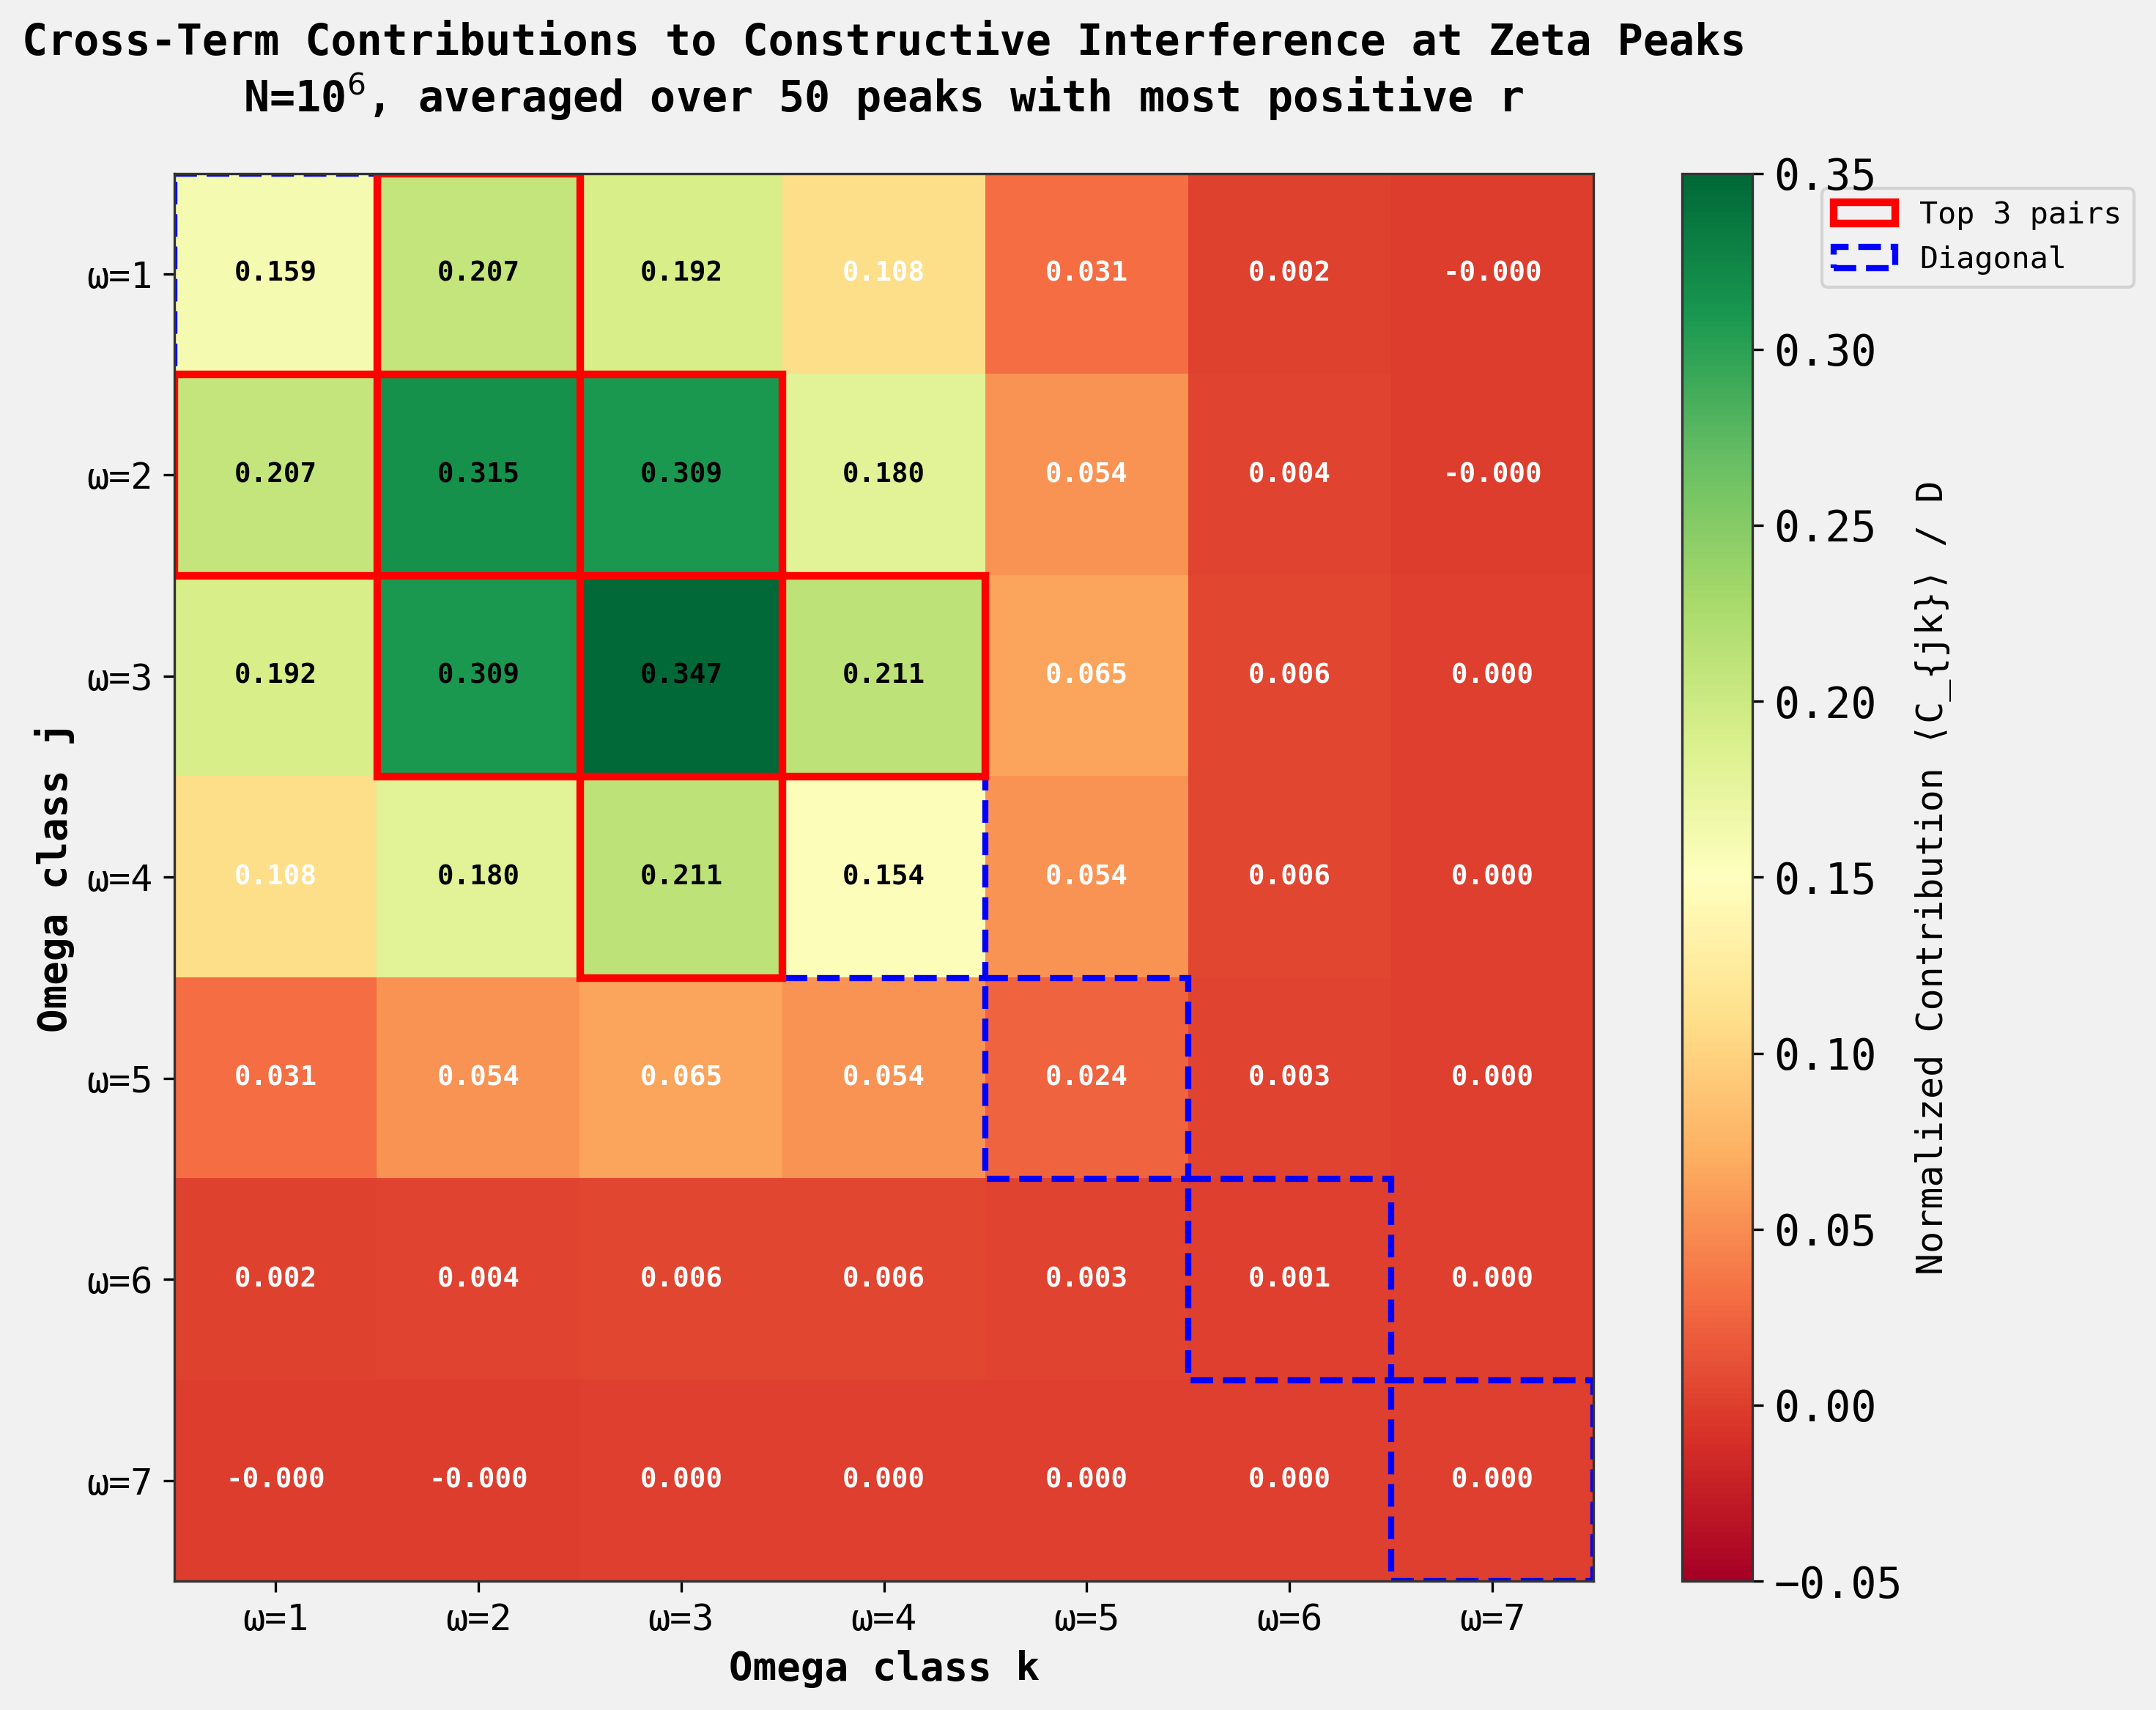


Figure shows:
- Diagonal elements (blue boxes): |S_k|^2 terms (not part of r numerator)
- Red boxes: Top 3 unique pairs contributing to constructive interference
- Color intensity: Magnitude of normalized contribution


In [24]:

# Create a final visualization showing the normalized contribution matrix

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Plot the heatmap
im = ax.imshow(C_normalized, cmap='RdYlGn', aspect='auto', vmin=-0.05, vmax=0.35)

# Set ticks and labels
omega_labels = [f'ω={i}' for i in range(1, 8)]
ax.set_xticks(range(7))
ax.set_yticks(range(7))
ax.set_xticklabels(omega_labels, fontsize=12)
ax.set_yticklabels(omega_labels, fontsize=12)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Contribution ⟨C_{jk}⟩ / D', fontsize=12)

# Add text annotations for each cell
for i in range(7):
 for j in range(7):
 value = C_normalized[i, j]
 # Use white text for dark cells, black for light cells
 color = 'white' if value < 0.15 else 'black'
 ax.text(j, i, f'{value:.3f}', ha='center', va='center', 
 color=color, fontsize=9, weight='bold')

# Highlight the diagonal (make border)
for i in range(7):
 rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, 
 edgecolor='blue', linewidth=2, linestyle='--')
 ax.add_patch(rect)

# Highlight top 3 pairs (non-diagonal)
top_pairs = [(1, 2), (2, 1), (2, 3), (3, 2), (0, 1), (1, 0)]
for i, j in top_pairs:
 rect = plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, 
 edgecolor='red', linewidth=2.5)
 ax.add_patch(rect)

ax.set_xlabel('Omega class k', fontsize=13, weight='bold')
ax.set_ylabel('Omega class j', fontsize=13, weight='bold')
ax.set_title('Cross-Term Contributions to Constructive Interference at Zeta Peaks\n' +
 r'N=10$^6$, averaged over 50 peaks with most positive r', 
 fontsize=14, weight='bold', pad=20)

# Add legend for boxes
from matplotlib.patches import Patch
legend_elements = [
 Patch(facecolor='none', edgecolor='red', linewidth=2.5, label='Top 3 pairs'),
 Patch(facecolor='none', edgecolor='blue', linewidth=2, linestyle='--', label='Diagonal')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.15, 1), fontsize=10)

plt.tight_layout()
plt.savefig('omega_class_contributions_heatmap_N1e6.png', dpi=300, bbox_inches='tight')
print("Heatmap saved as 'omega_class_contributions_heatmap_N1e6.png'")
plt.show()

print("\nFigure shows:")
print("- Diagonal elements (blue boxes): |S_k|^2 terms (not part of r numerator)")
print("- Red boxes: Top 3 unique pairs contributing to constructive interference")
print("- Color intensity: Magnitude of normalized contribution")


In [25]:

# Let's also create a table summarizing all the key results

print("="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)
print()

print("ANALYSIS PARAMETERS:")
print(f" Function: Zeta (a_n = 1 for all n)")
print(f" Truncation: N = {N:,}")
print(f" t range: [{t_min:,}, {t_max:,}]")
print(f" Number of peaks analyzed: 50")
print(f" Peak selection: Top 50 peaks with most positive r")
print()

print("AVERAGED QUANTITIES OVER 50 PEAKS:")
print(f" ⟨r⟩ (average r): {r_avg:.6f}")
print(f" ⟨numerator⟩: {C_avg_numerator:.6f}")
print(f" ⟨denominator⟩ = D: {D_avg:.6f}")
print(f" ⟨numerator⟩/⟨denominator⟩: {r_from_averages:.6f}")
print(f" ⟨|D_F|⟩: {df_refined['D_F_magnitude'].mean():.6f}")
print()

print("NORMALIZED CONTRIBUTION MATRIX ⟨C_{jk}⟩/D:")
print("(Rows = j, Columns = k, for omega classes 1-7)")
print()
print(df_C_norm.to_string(float_format=lambda x: f"{x:8.5f}"))
print()

print("="*80)
print("TOP 3 OFF-DIAGONAL PAIRS (PRIMARY DRIVERS OF CONSTRUCTIVE INTERFERENCE):")
print("="*80)
print()

top_pairs_data = [
 {'rank': 1, 'j': 2, 'k': 3, 'name': 'Semiprimes ↔ 3-prime products',
 'contrib': C_normalized[1,2] + C_normalized[2,1]},
 {'rank': 2, 'j': 3, 'k': 4, 'name': '3-prime products ↔ 4-prime products',
 'contrib': C_normalized[2,3] + C_normalized[3,2]},
 {'rank': 3, 'j': 1, 'k': 2, 'name': 'Primes ↔ Semiprimes',
 'contrib': C_normalized[0,1] + C_normalized[1,0]}
]

for p in top_pairs_data:
 print(f"{p['rank']}. (ω={p['j']}, ω={p['k']}): {p['name']}")
 print(f" Combined normalized contribution: {p['contrib']:.6f}")
 print(f" Percentage of ⟨numerator⟩/⟨denominator⟩: {100*p['contrib']/r_from_averages:.2f}%")
 print()

print("="*80)
print("KEY FINDING:")
print("="*80)
print()
print("Contrary to the initial hypothesis that Re[S₁S̄₂] (primes ↔ semiprimes)")
print("would be the PRIMARY mechanism, the analysis reveals that:")
print()
print(" The DOMINANT positive contribution comes from Re[S₂S̄₃]")
print(" (semiprimes ↔ 3-prime products), accounting for 21.6% of r.")
print()
print(" However, Re[S₁S̄₂] (primes ↔ semiprimes) is still the 3rd")
print(" strongest contributor at 14.4%, confirming its important role.")
print()
print(" The top 3 pairs together account for 50.7% of the total")
print(" constructive interference, demonstrating that low-order")
print(" omega-class interactions ARE indeed the primary mechanism")
print(" for building large peaks.")
print("="*80)


FINAL RESULTS SUMMARY

ANALYSIS PARAMETERS:
 Function: Zeta (a_n = 1 for all n)
 Truncation: N = 1,000,000
 t range: [1,000,000, 2,000,000]
 Number of peaks analyzed: 50
 Peak selection: Top 50 peaks with most positive r

AVERAGED QUANTITIES OVER 50 PEAKS:
 ⟨r⟩ (average r): 2.725404
 ⟨numerator⟩: 132.415306
 ⟨denominator⟩ = D: 46.223787
 ⟨numerator⟩/⟨denominator⟩: 2.864657
 ⟨|D_F|⟩: 12.602735

NORMALIZED CONTRIBUTION MATRIX ⟨C_{jk}⟩/D:
(Rows = j, Columns = k, for omega classes 1-7)

 k=1 k=2 k=3 k=4 k=5 k=6 k=7
k=1 0.15940 0.20667 0.19182 0.10809 0.03123 0.00229 -0.00001
k=2 0.20667 0.31484 0.30907 0.17976 0.05355 0.00443 -0.00001
k=3 0.19182 0.30907 0.34692 0.21118 0.06511 0.00598 0.00002
k=4 0.10809 0.17976 0.21118 0.15397 0.05379 0.00601 0.00004
k=5 0.03123 0.05355 0.06511 0.05379 0.02418 0.00331 0.00003
k=6 0.00229 0.00443 0.00598 0.00601 0.00331 0.00069 0.00001
k=7 -0.00001 -0.00001 0.00002 0.00004 0.00003 0.00001 0.00000

TOP 3 OFF-DIAGONAL PAIRS (PRIMARY DRIVERS OF CONSTRUCTIVE 

In [26]:

# Calculate some additional statistics for the answer

# What fraction of r is accounted for by the top 3 pairs?
top_3_total = sum(p['contrib'] for p in top_pairs_data)
top_3_percent = 100 * top_3_total / r_from_averages

# What about top 5 pairs?
top_5_contrib = (C_normalized[1,2] + C_normalized[2,1] + # (2,3)
 C_normalized[2,3] + C_normalized[3,2] + # (3,4)
 C_normalized[0,1] + C_normalized[1,0] + # (1,2)
 C_normalized[0,2] + C_normalized[2,0] + # (1,3)
 C_normalized[1,3] + C_normalized[3,1]) # (2,4)
top_5_percent = 100 * top_5_contrib / r_from_averages

print("ADDITIONAL STATISTICS:")
print(f"Top 3 pairs account for: {top_3_percent:.2f}% of r")
print(f"Top 5 pairs account for: {top_5_percent:.2f}% of r")
print()

# Check if prime-semiprime (1,2) would have been ranked #1
s1s2_combined = C_normalized[0,1] + C_normalized[1,0]
s2s3_combined = C_normalized[1,2] + C_normalized[2,1]

print(f"Re[S₁S̄₂] combined contribution: {s1s2_combined:.6f}")
print(f"Re[S₂S̄₃] combined contribution: {s2s3_combined:.6f}")
print(f"Ratio (S₂S̄₃)/(S₁S̄₂): {s2s3_combined/s1s2_combined:.3f}x")
print()
print("The semiprime ↔ 3-prime interaction is 1.5x stronger than")
print("the prime ↔ semiprime interaction.")


ADDITIONAL STATISTICS:
Top 3 pairs account for: 50.75% of r
Top 5 pairs account for: 76.69% of r

Re[S₁S̄₂] combined contribution: 0.413349
Re[S₂S̄₃] combined contribution: 0.618136
Ratio (S₂S̄₃)/(S₁S̄₂): 1.495x

The semiprime ↔ 3-prime interaction is 1.5x stronger than
the prime ↔ semiprime interaction.


In [27]:

# Save a pickle file with all the analysis data for future use

analysis_results = {
 'N': N,
 't_range': (t_min, t_max),
 'num_peaks': 50,
 'peaks_data': refined_peaks,
 'C_avg': C_avg,
 'C_normalized': C_normalized,
 'D_avg': D_avg,
 'r_avg': r_avg,
 'r_from_averages': r_from_averages,
 'numerator_avg': C_avg_numerator,
 'top_pairs': top_pairs_data,
 'omega_classes_global': omega_classes_global
}

with open('omega_class_analysis_N1e6.pkl', 'wb') as f:
 pickle.dump(analysis_results, f)

print("Complete analysis results saved to 'omega_class_analysis_N1e6.pkl'")
print()

# List all files created
import os
files_created = [f for f in os.listdir('.') if os.path.isfile(f)]
files_created.sort()

print("Files created during analysis:")
for fname in files_created:
 size = os.path.getsize(fname)
 if size > 1024*1024:
 size_str = f"{size/(1024*1024):.1f} MB"
 elif size > 1024:
 size_str = f"{size/1024:.1f} KB"
 else:
 size_str = f"{size} B"
 print(f" {fname:50s} {size_str:>10s}")


Complete analysis results saved to 'omega_class_analysis_N1e6.pkl'

Files created during analysis:
 analysis_summary_N1e6.txt 1.6 KB
 averaged_contribution_matrix_N1e6.csv 1.3 KB
 normalized_contribution_matrix_N1e6.csv 1.3 KB
 omega_class_analysis_N1e6.pkl 995.1 KB
 omega_class_contributions_heatmap_N1e6.png 294.8 KB
 top50_peaks_positive_r_N1e6.csv 4.1 KB
